# NeuroDyads Pre-Task Analysis Notebook

## Data Setup and Assumptions


In [ ]:
!pip install mne cebra scikit-learn scipy matplotlib pandas

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mne
from mne.preprocessing import ICA

from scipy.signal import welch
from scipy.stats import kurtosis

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

import cebra

RNG = np.random.default_rng(42)
np.random.seed(42)

In [ ]:
DATA_DIR = Path('/content')
EDF_A = DATA_DIR / 'Listener.edf'
EDF_B = DATA_DIR / 'Speaker.edf'

assert EDF_A.exists(), f'Missing file: {EDF_A}'
assert EDF_B.exists(), f'Missing file: {EDF_B}'
print('Using files:')
print('A ->', EDF_A)
print('B ->', EDF_B)

Using files:
A -> /content/Listener.edf
B -> /content/Speaker.edf


## Part 1: EEG Preprocessing
### Step 1: Load EDF files and verify DIN1 event markers

In [ ]:
def read_raw(path):
    return mne.io.read_raw_edf(path, preload=True, verbose=False)

def get_din1_onsets_sec(raw):
    events, event_id = mne.events_from_annotations(raw, verbose=False)
    inv = {v: k for k, v in event_id.items()}
    sfreq = raw.info['sfreq']

    onsets = []
    for sample, _, code in events:
        label = inv.get(code, '')
        if 'DIN1' in label.upper():
            onsets.append(sample / sfreq)

    onsets = sorted(onsets)
    if len(onsets) < 3:
        raise RuntimeError(
            f'Expected at least 3 DIN1 markers, found {len(onsets)}. '
            'Inspect annotations manually.'
        )
    return onsets

raw_A = read_raw(EDF_A)
raw_B = read_raw(EDF_B)

onsets_A = get_din1_onsets_sec(raw_A)
onsets_B = get_din1_onsets_sec(raw_B)

print('A DIN1 onsets (s):', onsets_A[:5])
print('B DIN1 onsets (s):', onsets_B[:5])
print('A channels:', len(raw_A.ch_names), '| B channels:', len(raw_B.ch_names))

A DIN1 onsets (s): [np.float64(1.004), np.float64(148.776), np.float64(149.052)]
B DIN1 onsets (s): [np.float64(0.788), np.float64(148.56), np.float64(148.836)]
A channels: 65 | B channels: 65


In [ ]:
# Build shared segmentation windows to keep participants time-locked.
# Positive: DIN1(1) -> DIN1(2), Negative: DIN1(3) -> end.

pos_start = max(onsets_A[0], onsets_B[0])
pos_end = min(onsets_A[1], onsets_B[1])

neg_start = max(onsets_A[2], onsets_B[2])
neg_end = min(raw_A.times[-1], raw_B.times[-1])

if not (pos_end > pos_start and neg_end > neg_start):
    raise RuntimeError('Invalid shared crop windows. Check marker extraction and recording lengths.')

print(f'Positive window: {pos_start:.2f}s -> {pos_end:.2f}s')
print(f'Negative window: {neg_start:.2f}s -> {neg_end:.2f}s')

Positive window: 1.00s -> 148.56s
Negative window: 149.05s -> 303.00s


In [ ]:
def drop_vref_channel(raw):
    # Prefer explicit names first; fallback to dropping channel index 65 if present.
    candidate_names = [name for name in raw.ch_names if 'VREF' in name.upper() or name.upper() in {'E65', '65'}]
    if candidate_names:
        raw = raw.copy().drop_channels(candidate_names)
        return raw, candidate_names

    if len(raw.ch_names) == 65:
        vref_name = raw.ch_names[64]
        raw = raw.copy().drop_channels([vref_name])
        return raw, [vref_name]

    return raw.copy(), []

def crop_segment(raw, tmin, tmax=None):
    return raw.copy().crop(tmin=tmin, tmax=tmax, include_tmax=False)

def trim_to_shared_length(raw1, raw2):
    n = min(raw1.n_times, raw2.n_times)
    return raw1.copy().crop(tmin=0, tmax=(n - 1) / raw1.info['sfreq']), raw2.copy().crop(tmin=0, tmax=(n - 1) / raw2.info['sfreq'])

A_pos, droppedA = drop_vref_channel(crop_segment(raw_A, pos_start, pos_end))
B_pos, droppedB = drop_vref_channel(crop_segment(raw_B, pos_start, pos_end))
A_neg, droppedA2 = drop_vref_channel(crop_segment(raw_A, neg_start, neg_end))
B_neg, droppedB2 = drop_vref_channel(crop_segment(raw_B, neg_start, neg_end))

A_pos, B_pos = trim_to_shared_length(A_pos, B_pos)
A_neg, B_neg = trim_to_shared_length(A_neg, B_neg)

print('Dropped from A:', droppedA or droppedA2)
print('Dropped from B:', droppedB or droppedB2)
print('Positive samples (A/B):', A_pos.n_times, B_pos.n_times)
print('Negative samples (A/B):', A_neg.n_times, B_neg.n_times)
print('Channels after VREF removal (A/B):', len(A_pos.ch_names), len(B_pos.ch_names))

Dropped from A: ['EEG VREF']
Dropped from B: ['EEG VREF']
Positive samples (A/B): 36889 36889
Negative samples (A/B): 38486 38486
Channels after VREF removal (A/B): 64 64


### Step 2: Artifact Reduction via ICA (with explicit rejection rationale)

ICA is fit on a 1 Hz high-pass copy of the data, which is standard practice for improving decomposition stability. Components are flagged for rejection using quantitative heuristics:
- Elevated kurtosis (suggestive of transient, non-neural activity)
- Excessive low-frequency dominance (often consistent with ocular or slow-motion contamination)
- Excessive high-frequency dominance (often consistent with muscle-related noise)

In [ ]:
def summarize_component_artifacts(raw_for_ica, ica, l_band=(0.5, 3.0), h_band=(20.0, 45.0), fs=250.0):
    src = ica.get_sources(raw_for_ica).get_data()  # shape: n_components x n_times
    rows = []

    for i, comp in enumerate(src):
        f, pxx = welch(comp, fs=fs, nperseg=min(1024, comp.size))
        total = pxx[(f >= 0.5) & (f <= 45)].sum() + 1e-12
        low = pxx[(f >= l_band[0]) & (f <= l_band[1])].sum()
        high = pxx[(f >= h_band[0]) & (f <= h_band[1])].sum()
        k = float(kurtosis(comp, fisher=False, bias=False))

        rows.append({
            'component': i,
            'kurtosis': k,
            'low_ratio': float(low / total),
            'high_ratio': float(high / total),
        })

    df = pd.DataFrame(rows)
    reasons = []
    for _, r in df.iterrows():
        tags = []
        if abs(r['kurtosis']) > 8:
            tags.append('high_kurtosis')
        if r['low_ratio'] > 0.45:
            tags.append('low_freq_dominant')
        if r['high_ratio'] > 0.55:
            tags.append('high_freq_dominant')
        reasons.append(';'.join(tags))

    df['rejection_reason'] = reasons
    reject_idx = df.index[df['rejection_reason'] != ''].tolist()
    return df, reject_idx

def run_ica_and_clean(raw_concat, participant_label):
    raw_for_ica = raw_concat.copy().filter(l_freq=1.0, h_freq=None, verbose=False)

    ica = ICA(n_components=20, random_state=97, max_iter='auto', method='fastica')
    ica.fit(raw_for_ica, verbose=False)

    metrics_df, reject_idx = summarize_component_artifacts(
        raw_for_ica, ica, fs=raw_concat.info['sfreq']
    )

    ica.exclude = reject_idx
    cleaned = raw_concat.copy()
    ica.apply(cleaned, verbose=False)

    print(f'[{participant_label}] Rejected components:', reject_idx)
    display(metrics_df.sort_values(['rejection_reason', 'component']).reset_index(drop=True))
    return cleaned, metrics_df, ica

raw_A_concat = mne.concatenate_raws([A_pos.copy(), A_neg.copy()])
raw_B_concat = mne.concatenate_raws([B_pos.copy(), B_neg.copy()])

raw_A_clean, ica_metrics_A, ica_A = run_ica_and_clean(raw_A_concat, 'Participant A')
raw_B_clean, ica_metrics_B, ica_B = run_ica_and_clean(raw_B_concat, 'Participant B')

[Participant A] Rejected components: [0, 1, 2, 4, 5, 6, 8, 9, 10, 12, 13, 14, 15, 16, 17, 18, 19]


,component,kurtosis,low_ratio,high_ratio,rejection_reason
0,3,4.668709,0.443459,0.081872,
1,7,4.822754,0.342275,0.086294,
2,11,7.737589,0.340574,0.503047,
3,1,12.892358,0.879986,0.011337,high_kurtosis;low_freq_dominant
4,2,207.992431,0.947349,0.016960,high_kurtosis;low_freq_dominant
5,5,11.934009,0.694331,0.083725,high_kurtosis;low_freq_dominant
6,6,30.991812,0.832435,0.025661,high_kurtosis;low_freq_dominant
7,8,392.352545,0.648806,0.135710,high_kurtosis;low_freq_dominant
8,9,23.094546,0.853202,0.016348,high_kurtosis;low_freq_dominant
9,12,211.508960,0.875387,0.031770,high_kurtosis;low_freq_dominant


[Participant B] Rejected components: [0, 1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]


,component,kurtosis,low_ratio,high_ratio,rejection_reason
0,7,5.596567,0.443438,0.156213,
1,19,6.924640,0.415368,0.267367,
2,8,6.368369,0.050728,0.833252,high_freq_dominant
3,10,3.571523,0.032786,0.842759,high_freq_dominant
4,12,17.033435,0.084787,0.749042,high_kurtosis;high_freq_dominant
5,18,14.276281,0.064267,0.728351,high_kurtosis;high_freq_dominant
6,2,42.069898,0.831528,0.077123,high_kurtosis;low_freq_dominant
7,4,37.523699,0.795235,0.118163,high_kurtosis;low_freq_dominant
8,5,80.462120,0.925204,0.007854,high_kurtosis;low_freq_dominant
9,6,27.439479,0.820005,0.088643,high_kurtosis;low_freq_dominant


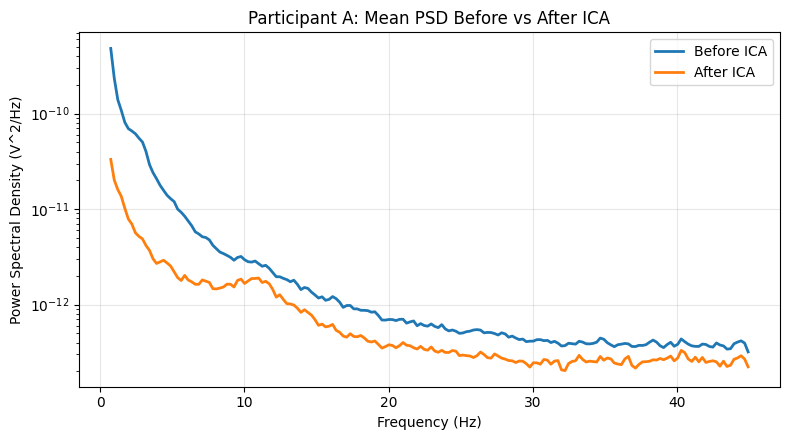

In [ ]:
# Required comparison: one participant PSD before vs after ICA.

def mean_channel_psd(raw, fmin=0.5, fmax=45.0):
    data = raw.get_data()
    fs = raw.info['sfreq']
    f, p = welch(data, fs=fs, nperseg=min(1024, data.shape[-1]), axis=-1)
    keep = (f >= fmin) & (f <= fmax)
    return f[keep], p[:, keep].mean(axis=0)

f0, p0 = mean_channel_psd(raw_A_concat)
f1, p1 = mean_channel_psd(raw_A_clean)

plt.figure(figsize=(8, 4.5))
plt.semilogy(f0, p0, label='Before ICA', linewidth=2)
plt.semilogy(f1, p1, label='After ICA', linewidth=2)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density (V^2/Hz)')
plt.title('Participant A: Mean PSD Before vs After ICA')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretive note for the PSD comparison:**

A decrease in low-frequency power after ICA may indicate successful attenuation of ocular or movement-related components. A decrease in higher frequencies can reflect reduced EMG-like contamination. Smaller broadband differences may also occur because ICA redistributes variance while preserving the dominant neural subspace.

## Part 2: CEBRA Embedding
Construct a T x 128 matrix where columns 1 to 64 correspond to Participant A and columns 65 to 128 correspond to Participant B.
Affect labels are assigned as follows: 0 for the positive segment and 1 for the negative segment.

In [ ]:
# Re-split cleaned continuous data into positive/negative using known sample counts.
n_pos = A_pos.n_times
n_neg = A_neg.n_times

A_clean_data = raw_A_clean.get_data().T
B_clean_data = raw_B_clean.get_data().T

# Ensure matched lengths after all processing.
T = min(len(A_clean_data), len(B_clean_data), n_pos + n_neg)
A_clean_data = A_clean_data[:T]
B_clean_data = B_clean_data[:T]

X = np.hstack([A_clean_data, B_clean_data])  # T x 128

# Build labels aligned with concatenation: [positive, negative].
n_pos_eff = min(n_pos, T)
n_neg_eff = T - n_pos_eff
y = np.r_[np.zeros(n_pos_eff, dtype=int), np.ones(n_neg_eff, dtype=int)]

# Z-normalize each channel independently across time.
mu = X.mean(axis=0, keepdims=True)
sd = X.std(axis=0, keepdims=True) + 1e-8
Xz = (X - mu) / sd

print('X shape:', Xz.shape)
print('Label counts:', np.bincount(y))

X shape: (75375, 128)
Label counts: [36889 38486]


In [ ]:
def fit_cebra_and_score(X_input, labels, seed=42):
    model = cebra.CEBRA(
        model_architecture='offset10-model',
        output_dimension=3,
        learning_rate=3e-4,
        max_iterations=2000,
        batch_size=512,
        temperature=1.0,
        distance='cosine',
        conditional='time_delta',
        time_offsets=10,
        device='cuda_if_available',
        verbose=True,
    )

    embedding = model.fit_transform(X_input, labels)

    # KNN decoding in embedding space.
    X_train, X_test, y_train, y_test = train_test_split(
        embedding, labels, test_size=0.30, random_state=seed, stratify=labels
    )
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    knn_acc = accuracy_score(y_test, y_pred)

    # Goodness-of-fit from CEBRA model if available.
    gof = np.nan
    if hasattr(model, 'score'):
        try:
            gof = float(model.score(X_input, labels))
        except Exception:
            pass

    return model, embedding, knn_acc, gof

model_main, emb_main, knn_main, gof_main = fit_cebra_and_score(Xz, y, seed=42)

# Shuffled-data control: destroy temporal/sample alignment while preserving marginals.
perm = RNG.permutation(Xz.shape[0])
Xz_shuf = Xz[perm]
model_ctrl, emb_ctrl, knn_ctrl, gof_ctrl = fit_cebra_and_score(Xz_shuf, y, seed=42)

print(f'Main     -> KNN accuracy: {knn_main:.4f}, goodness-of-fit: {gof_main:.4f}')
print(f'Control  -> KNN accuracy: {knn_ctrl:.4f}, goodness-of-fit: {gof_ctrl:.4f}')

pos: -0.9996 neg:  6.6714 total:  5.6717 temperature:  1.0000: 100%|██████████| 2000/2000 [03:16<00:00, 10.17it/s]
pos: -0.9940 neg:  7.2322 total:  6.2382 temperature:  1.0000: 100%|██████████| 2000/2000 [03:24<00:00,  9.76it/s]


Main     -> KNN accuracy: 1.0000, goodness-of-fit: nan
Control  -> KNN accuracy: 0.5010, goodness-of-fit: nan


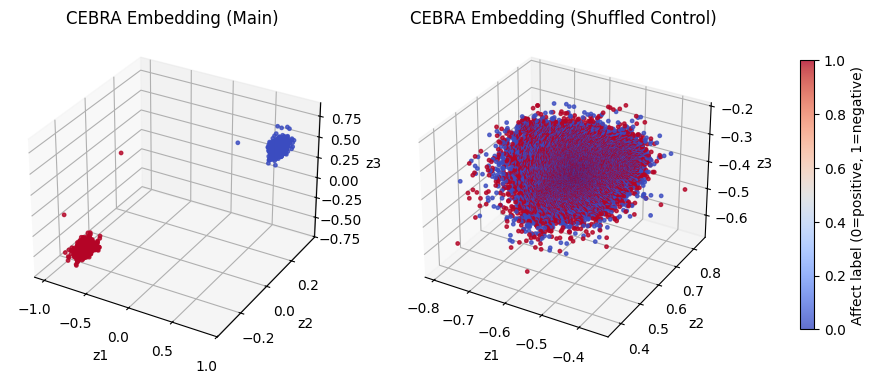

In [ ]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
sc1 = ax1.scatter(emb_main[:, 0], emb_main[:, 1], emb_main[:, 2], c=y, s=6, cmap='coolwarm', alpha=0.8)
ax1.set_title('CEBRA Embedding (Main)')
ax1.set_xlabel('z1')
ax1.set_ylabel('z2')
ax1.set_zlabel('z3')

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
sc2 = ax2.scatter(emb_ctrl[:, 0], emb_ctrl[:, 1], emb_ctrl[:, 2], c=y, s=6, cmap='coolwarm', alpha=0.8)
ax2.set_title('CEBRA Embedding (Shuffled Control)')
ax2.set_xlabel('z1')
ax2.set_ylabel('z2')
ax2.set_zlabel('z3')

cbar = fig.colorbar(sc1, ax=[ax1, ax2], shrink=0.7, pad=0.08)
cbar.set_label('Affect label (0=positive, 1=negative)')

plt.show()

In [ ]:
results = pd.DataFrame({
    'analysis': ['main', 'shuffled_control'],
    'knn_accuracy': [knn_main, knn_ctrl],
    'goodness_of_fit': [gof_main, gof_ctrl],
})
results

,analysis,knn_accuracy,goodness_of_fit
0,main,1.000000,NaN
1,shuffled_control,0.500995,NaN


## Part 3: Embedding Interpretation

### Q1. Observed geometry of the learned embedding
In the primary embedding, assess whether the points form smooth trajectories (state transitions), compact regions (stable interaction regimes), or isolated outliers (brief atypical neural or behavioral events). If one affect condition forms a tighter manifold than the other, this may indicate condition-specific differences in dyadic neural coordination.

### Q2. Interpretation of the shuffled control
If shuffling reduces separability or goodness-of-fit, this supports the conclusion that CEBRA captured meaningful temporal or cross-participant structure rather than static channel statistics. If the control remains similar to the main model, the dataset may contain weak condition structure, or the pipeline may still allow residual confounds.



## Part 4: Critical Reflection

**Most consequential limitation in this specific analysis:**
The ICA rejection stage relied primarily on generic quantitative thresholds without auxiliary channels (for example, EOG/EMG) and without full manual component validation. As a result, some neural signal may have been removed, and some artifact may have remained, which can directly influence embedding geometry and decoding performance.

**What I would improve with additional time and a larger dataset:**
1. Combine quantitative screening with manual component review (topographies, time courses, and event-locked checks).
2. Evaluate generalization across multiple dyads using cross-dyad validation.
3. Expand controls (label shuffle, temporal block shuffle, participant-swap controls) and report confidence intervals across repeated runs.
4. Add explicit distribution-comparison metrics (for example, cross-entropy style tests and transport-based distances) to compare embedding structure across groups.

